In [ ]:
import mysql.connector

In [ ]:
!service mysql start

 * Starting MySQL database server mysqld
   ...done.


In [ ]:
!mysql -u root -e "CREATE DATABASE IF NOT EXISTS agriculture;"

In [ ]:

# INSTALLATION + LANCEMENT MYSQL

!pip install mysql-connector-python > /dev/null
!apt-get update -y > /dev/null
!DEBIAN_FRONTEND=noninteractive apt-get install -y mysql-server > /dev/null

!service mysql start

# UPLOAD DU FICHIER SQL

from google.colab import files
uploaded = files.upload()

sql_file = list(uploaded.keys())[0]
print("Fichier uploadé :", sql_file)

# CONFIGURATION MYSQL

!mysql -u root -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY ''; FLUSH PRIVILEGES;"


# Importer dans la bonne base
!mysql -u root agriculture < "{sql_file}"

# Vérifier tables
!mysql -u root -e "USE agriculture; SHOW TABLES;"

# CONNEXION PYTHON


bdd = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="agriculture"
)

print("Connexion SQL OK ✅")



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting MySQL database server mysqld
   ...done.


Saving agriculture(1).sql to agriculture(1) (1).sql
Fichier uploadé : agriculture(1) (1).sql
+------------------------+
| Tables_in_agriculture  |
+------------------------+
| adapter                |
| contrainte_temperature |
| culture                |
| releve_meteo           |
| saisonnalite           |
| station_meteo          |
| type_sol               |
| villes                 |
+------------------------+
Connexion SQL OK ✅


Objectif : prédire les conditions météorologiques (notamment la température) afin d’alimenter un système d’aide à la décision agricole (semis, irrigation, culture adaptée).

```
# Ce texte est au format code
```



Nous utilisons les données météorologiques de 2022 à 2025 comme jeu d’entraînement, puis nous évaluons les modèles sur des données réelles de début 2026 afin de simuler une situation de prédiction réelle.

Régression linéaire

/tmp/ipykernel_547/2524616580.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== Régression linéaire (en °C) ===
MAE : 0.2359768644137453 °C
MSE : 0.07268249359852637
RMSE : 0.26959690947510206 °C
R² : 0.9877919986798545
Coefficients : [-0.23809274  0.99812749  0.02263156 -0.0164501 ]
Intercept : 22.697915678107663


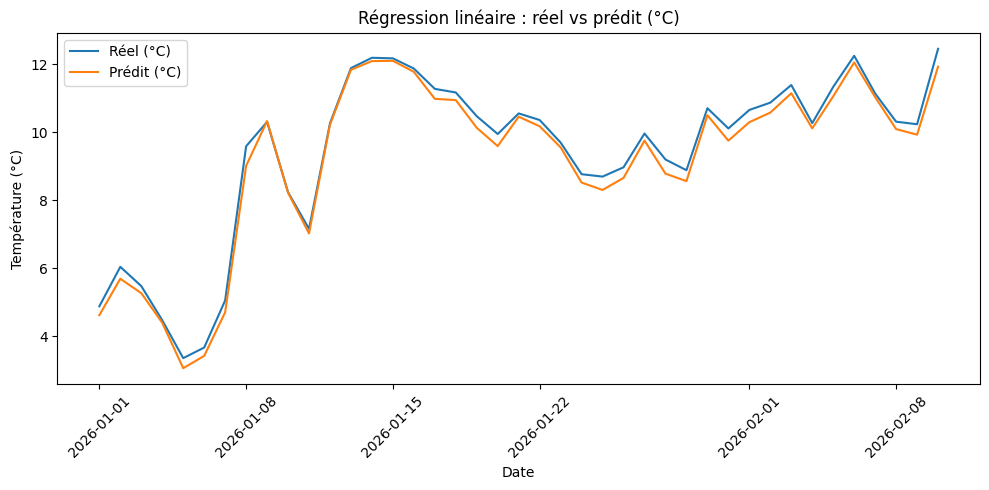

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# CHARGER LES DONNÉES

query = "SELECT * FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

# PRÉPARATION

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'], dayfirst=True)

train = train.sort_values('date')
test = test.sort_values('date')

# CONVERSION EN °C

def kelvin_to_celsius(df):
    df['temperature'] = df['temperature'] - 273.15
    df['point_de_rose'] = df['point_de_rose'] - 273.15
    df['temperature_min_sol_12h'] = df['temperature_min_sol_12h'] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

# Agrégation journalière

cols = [
    'temperature',
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

train = train.groupby('date')[cols].mean()
test = test.groupby('date')[cols].mean()

# Fréquence journalière
train = train.asfreq('D').interpolate()
test = test.asfreq('D').interpolate()

# VARIABLES

features = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

X_train = train[features]
y_train = train['temperature']

X_test = test[features]
y_test = test['temperature']

# MODÈLE

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

# ÉVALUATION

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Régression linéaire (en °C) ===")
print("MAE :", mae_lr, "°C")
print("MSE :", mse_lr)
print("RMSE :", rmse_lr, "°C")
print("R² :", r2_lr)

print("Coefficients :", model_lr.coef_)
print("Intercept :", model_lr.intercept_)

# GRAPHIQUE

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test.values, label="Réel (°C)")
plt.plot(y_test.index, y_pred_lr, label="Prédit (°C)")

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Régression linéaire : réel vs prédit (°C)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La régression linéaire donne des résultats visuellement très satisfaisants, avec des prédictions proches des valeurs réelles. Cependant, ce modèle utilise des variables explicatives observées en 2026, comme l’humidité ou les précipitations, qui ne sont pas disponibles dans un contexte de prévision réelle. Ainsi, il s’agit davantage d’un modèle explicatif que prédictif. De plus, il ne prend pas en compte la dépendance temporelle des données, contrairement aux modèles de séries temporelles.

Random Forest avec lags (températures passées)

/tmp/ipykernel_547/3900458420.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, bdd)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForest

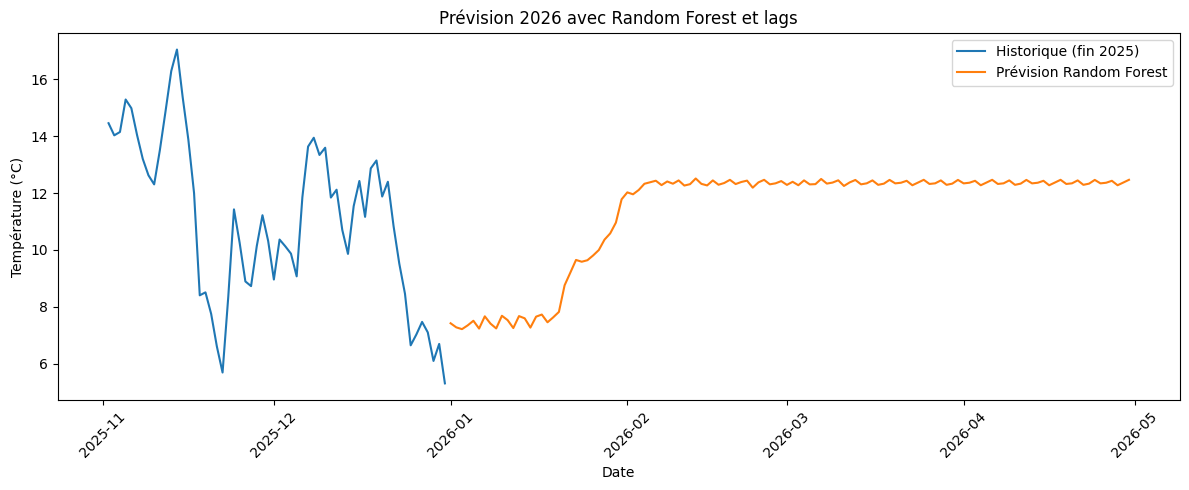

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
df = pd.read_sql(query, bdd)

# =========================
# 2) PRÉPARATION
# =========================

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Kelvin -> Celsius
df["temperature"] = df["temperature"] - 273.15

# Agrégation journalière
df = df.groupby("date")["temperature"].mean()

# Fréquence journalière + interpolation
df = df.asfreq("D").interpolate()

# On remet en DataFrame
df = df.to_frame(name="temperature")

# =========================
# 3) CRÉATION DES LAGS
# =========================

def create_lag_features(data, n_lags=7):
    data = data.copy()
    for lag in range(1, n_lags + 1):
        data[f"lag_{lag}"] = data["temperature"].shift(lag)
    return data

n_lags = 7
df_lags = create_lag_features(df, n_lags=n_lags)
df_lags = df_lags.dropna()

# =========================
# 4) TRAIN DU MODÈLE
# =========================

feature_cols = [f"lag_{lag}" for lag in range(1, n_lags + 1)]

X_train = df_lags[feature_cols]
y_train = df_lags["temperature"]

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_rf.fit(X_train, y_train)

# =========================
# 5) PRÉDICTION FUTURE SANS CSV
# =========================

# Exemple : 120 jours (~4 mois)
n_future = 120

# On récupère les dernières températures connues
last_values = df["temperature"].iloc[-n_lags:].tolist()

future_preds = []

for _ in range(n_future):
    # attention : ordre des lags
    # lag_1 = hier, lag_2 = avant-hier, etc.
    X_next = np.array(last_values[::-1]).reshape(1, -1)

    next_pred = model_rf.predict(X_next)[0]
    future_preds.append(next_pred)

    # on met à jour l'historique glissant
    last_values.append(next_pred)
    last_values = last_values[-n_lags:]

# =========================
# 6) DATES FUTURES
# =========================

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=n_future,
    freq="D"
)

forecast_rf = pd.Series(future_preds, index=future_dates)

# =========================
# 7) GRAPHIQUE
# =========================

plt.figure(figsize=(12, 5))

plt.plot(
    df.index[-60:],
    df["temperature"].iloc[-60:],
    label="Historique (fin 2025)"
)

plt.plot(
    forecast_rf.index,
    forecast_rf.values,
    label="Prévision Random Forest"
)

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Prévision 2026 avec Random Forest et lags")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Random Forest avec lags ===
MAE : 1.9593630571625233 °C
MSE : 5.6712459859700965
RMSE : 2.3814377980476618 °C
R² : 0.04743804104986249


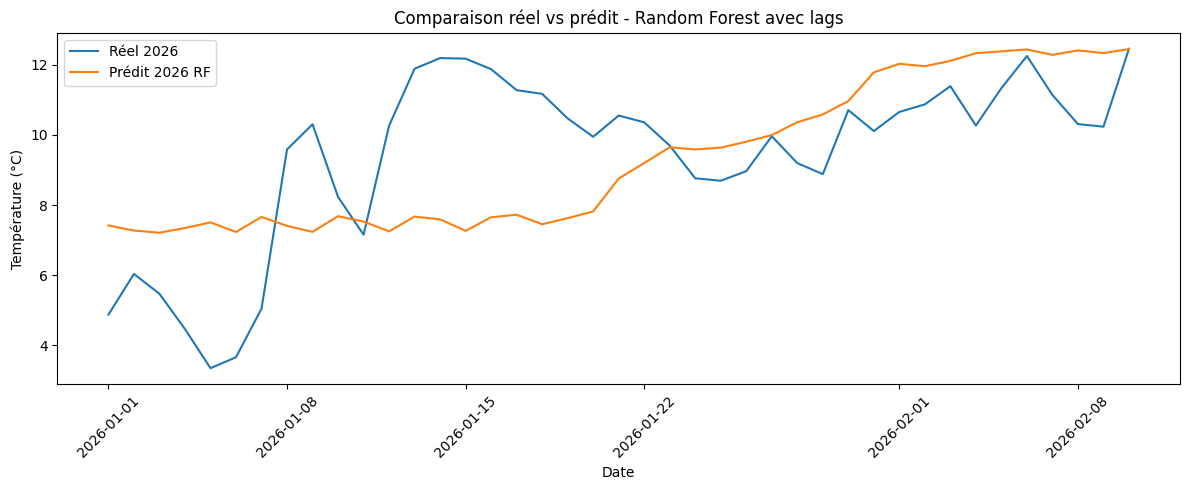

In [ ]:
test = pd.read_csv("meteo_2026_a_predire.csv")

test["date"] = pd.to_datetime(test["date"], dayfirst=True)
test["temperature"] = test["temperature"] - 273.15

test = test.groupby("date")["temperature"].mean()
test = test.asfreq("D").interpolate()

# on aligne la comparaison
n_compare = min(len(test), len(forecast_rf))

y_true = test.iloc[:n_compare]
y_pred = forecast_rf.iloc[:n_compare]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("=== Random Forest avec lags ===")
print("MAE :", mae, "°C")
print("MSE :", mse)
print("RMSE :", rmse, "°C")
print("R² :", r2)

plt.figure(figsize=(12, 5))
plt.plot(y_true.index, y_true.values, label="Réel 2026")
plt.plot(y_pred.index, y_pred.values, label="Prédit 2026 RF")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Comparaison réel vs prédit - Random Forest avec lags")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle Random Forest avec lags ne permet pas de capturer correctement la dynamique de la température. Les prédictions sont trop lissées et ne reproduisent pas les variations réelles. De plus, le coefficient R² est très faible, ce qui montre que le modèle explique très peu la variance des données.

Cela s’explique par le fait que Random Forest n’est pas conçu pour modéliser explicitement les séries temporelles. Il ne prend pas en compte la dépendance temporelle ni la saisonnalité. C’est pourquoi nous avons choisi de nous orienter vers des modèles de séries temporelles comme ARIMA et SARIMA, qui sont spécifiquement adaptés à ce type de données.

Random Forest (Simple)

=== Random Forest ===
MAE : 0.39104562910203117
MSE : 0.3845824807874045
RMSE : 0.6201471444644444
R² : 0.9354042053222473


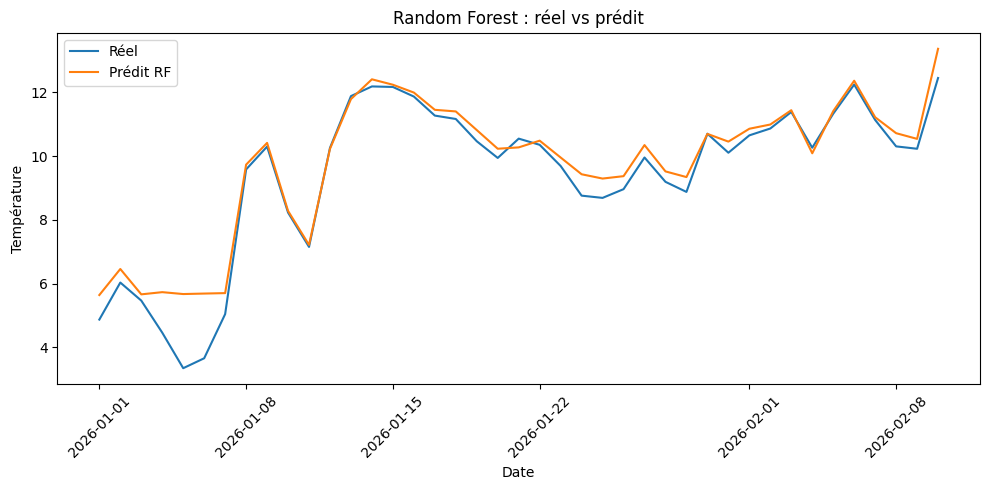

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Réel")
plt.plot(y_test.index, y_pred_rf, label="Prédit RF")
plt.xlabel("Date")
plt.ylabel("Température")
plt.title("Random Forest : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ARIMA

/tmp/ipykernel_547/1162625555.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== ARIMA ===
MAE : 4.21842348122446 °C
MSE : 21.325323376836845
RMSE : 4.617934968883477 °C
R² : -2.5818745759464887
            Réel 2026  Prédit 2026 ARIMA
date                                    
2026-01-01   4.875364           4.780242
2026-01-02   6.036444           5.168140
2026-01-03   5.470833           5.452401
2026-01-04   4.465405           5.490096
2026-01-05   3.350640           5.599772


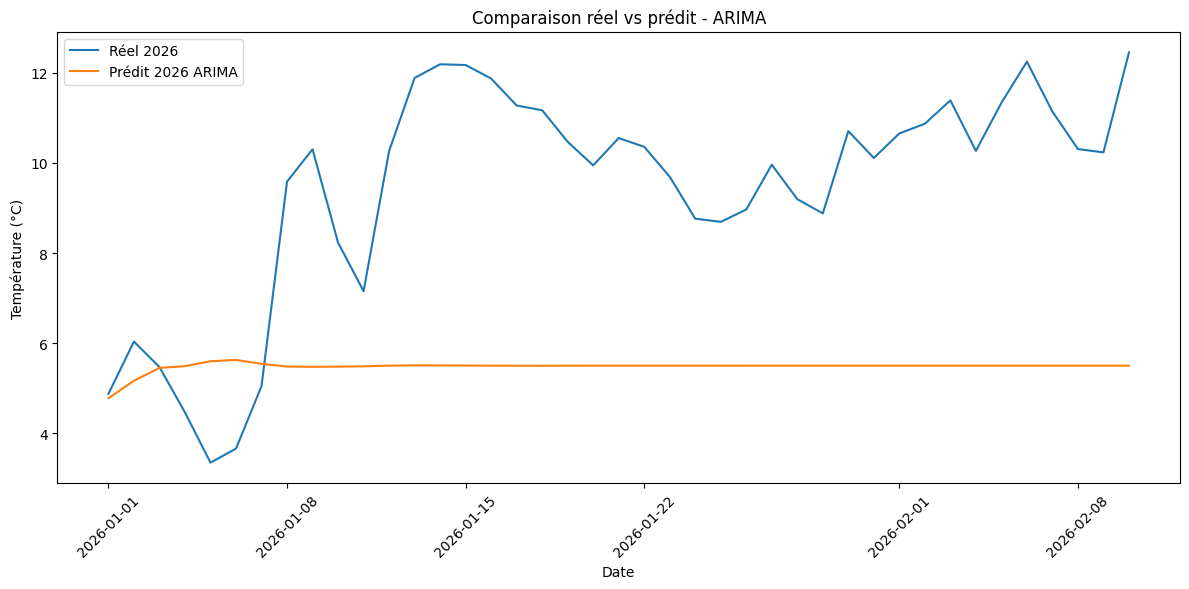

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

# =========================
# 1. CHARGER LES DONNÉES
# =========================

query = "SELECT * FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

# =========================
# 2. PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# =========================
# 3. CONVERSION EN °C
# =========================

def kelvin_to_celsius(df):
    df = df.copy()
    df["temperature"] = df["temperature"] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

# =========================
# 4. AGRÉGATION JOURNALIÈRE
# =========================

train = train.groupby("date")["temperature"].mean()
test = test.groupby("date")["temperature"].mean()

# =========================
# 5. FRÉQUENCE JOURNALIÈRE
# =========================

train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

# =========================
# 6. MODÈLE ARIMA
# =========================

# Exemple de paramètres ARIMA
model_arima = ARIMA(train, order=(5, 1, 0))
model_arima_fit = model_arima.fit()

# =========================
# 7. PRÉDICTION 2026
# =========================

y_pred_arima = model_arima_fit.forecast(steps=len(test))
y_pred_arima.index = test.index

# =========================
# 8. ÉVALUATION
# =========================

mae_arima = mean_absolute_error(test, y_pred_arima)
mse_arima = mean_squared_error(test, y_pred_arima)
rmse_arima = np.sqrt(mse_arima)
r2_arima = r2_score(test, y_pred_arima)

print("=== ARIMA ===")
print("MAE :", mae_arima, "°C")
print("MSE :", mse_arima)
print("RMSE :", rmse_arima, "°C")
print("R² :", r2_arima)

# =========================
# 9. TABLEAU COMPARATIF
# =========================

comparaison_arima = pd.DataFrame({
    "Réel 2026": test,
    "Prédit 2026 ARIMA": y_pred_arima
})

print(comparaison_arima.head())

# =========================
# 10. GRAPHIQUE
# =========================

plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label="Réel 2026")
plt.plot(y_pred_arima.index, y_pred_arima.values, label="Prédit 2026 ARIMA")

plt.title("Comparaison réel vs prédit - ARIMA")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le modèle ARIMA testé ne permet pas de reproduire correctement la dynamique de la température. Les prédictions sont quasi constantes et ne suivent pas les variations observées. Cela s’explique notamment par l’absence de composante saisonnière et par une paramétrisation trop simple du modèle.

Afin d’améliorer les performances du modèle, il est nécessaire d’intégrer une composante saisonnière. Nous avons donc choisi d’utiliser le modèle SARIMA, qui permet de prendre en compte à la fois la dépendance temporelle et la saisonnalité des données, ce qui est particulièrement pertinent pour la température.

SARIMAX

/tmp/ipykernel_547/2722648090.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== SARIMA ===
MAE : 4.950370245387905 °C
MSE : 29.45815519336033
RMSE : 5.427536751912449 °C
R² : -3.947892947592636
            Réel 2026  Prédit 2026 SARIMA
date                                     
2026-01-01   4.875364            4.668822
2026-01-02   6.036444            4.825758
2026-01-03   5.470833            4.612268
2026-01-04   4.465405            4.570923
2026-01-05   3.350640            4.681557


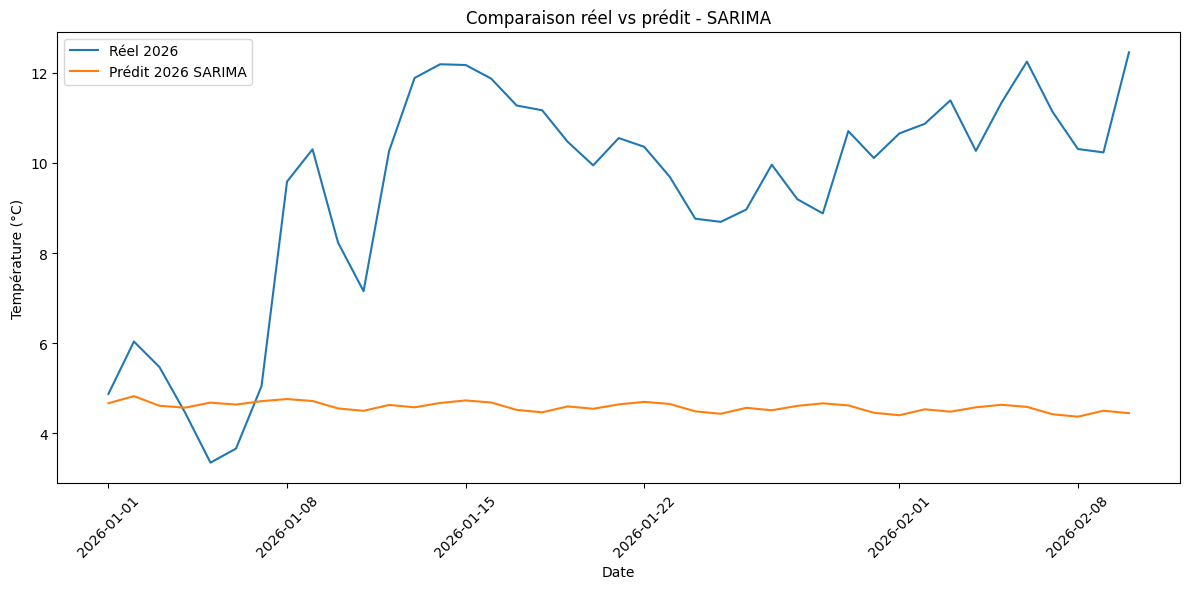

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1. CHARGER LES DONNÉES
# =========================

query = "SELECT * FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

# =========================
# 2. PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# =========================
# 3. CONVERSION EN °C
# =========================

def kelvin_to_celsius(df):
    df = df.copy()
    df["temperature"] = df["temperature"] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

# =========================
# 4. AGRÉGATION JOURNALIÈRE
# =========================

train = train.groupby("date")["temperature"].mean()
test = test.groupby("date")["temperature"].mean()

# =========================
# 5. FRÉQUENCE JOURNALIÈRE
# =========================

train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

# =========================
# 6. MODÈLE SARIMA
# =========================
# order = (p, d, q)
# seasonal_order = (P, D, Q, s)
# Exemple ici avec une saisonnalité hebdomadaire s = 7

model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_sarima_fit = model_sarima.fit(disp=False)

# =========================
# 7. PRÉDICTION 2026
# =========================

y_pred_sarima = model_sarima_fit.forecast(steps=len(test))
y_pred_sarima.index = test.index

# =========================
# 8. ÉVALUATION
# =========================

mae_sarima = mean_absolute_error(test, y_pred_sarima)
mse_sarima = mean_squared_error(test, y_pred_sarima)
rmse_sarima = np.sqrt(mse_sarima)
r2_sarima = r2_score(test, y_pred_sarima)

print("=== SARIMA ===")
print("MAE :", mae_sarima, "°C")
print("MSE :", mse_sarima)
print("RMSE :", rmse_sarima, "°C")
print("R² :", r2_sarima)

# =========================
# 9. TABLEAU COMPARATIF
# =========================

comparaison_sarima = pd.DataFrame({
    "Réel 2026": test,
    "Prédit 2026 SARIMA": y_pred_sarima
})

print(comparaison_sarima.head())

# =========================
# 10. GRAPHIQUE
# =========================

plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label="Réel 2026")
plt.plot(y_pred_sarima.index, y_pred_sarima.values, label="Prédit 2026 SARIMA")

plt.title("Comparaison réel vs prédit - SARIMA")
plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_547/3706328364.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


date
2022-01-31     9.541434
2022-02-28    11.206093
2022-03-31    12.630924
2022-04-30    14.045257
2022-05-31    18.041148
Freq: ME, Name: temperature, dtype: float64
date
2025-08-31    21.243919
2025-09-30    17.473606
2025-10-31    14.961238
2025-11-30    12.092311
2025-12-31    10.313370
Freq: ME, Name: temperature, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


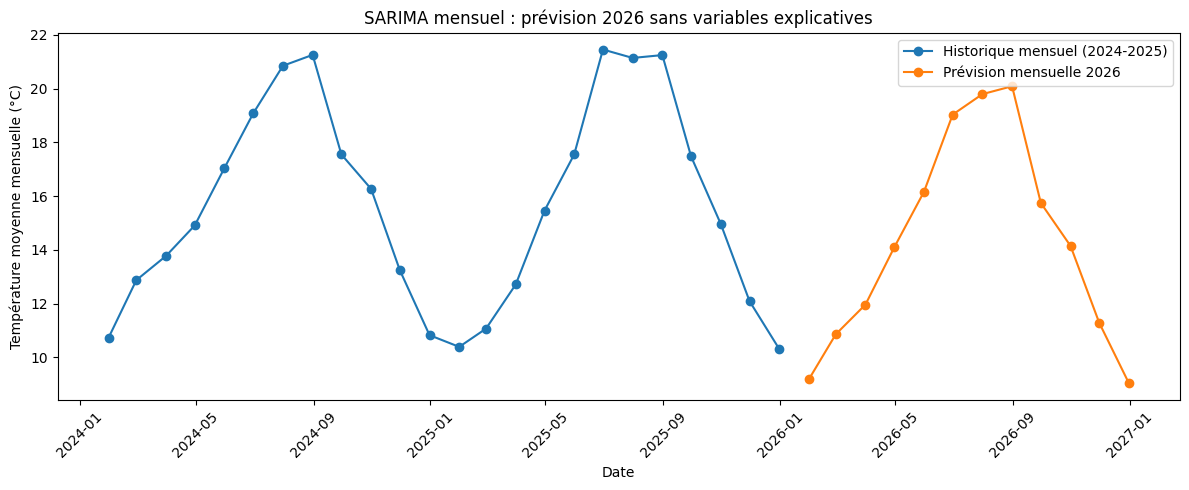

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

# =========================
# 2) PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
train = train.sort_values("date")

# Conversion Kelvin -> Celsius
train["temperature"] = train["temperature"] - 273.15

# Agrégation mensuelle
train_monthly = train.groupby(pd.Grouper(key="date", freq="ME"))["temperature"].mean()

# Vérification
print(train_monthly.head())
print(train_monthly.tail())

# =========================
# 3) MODÈLE SARIMA MENSUEL
# =========================

model = SARIMAX(
    train_monthly,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),  # saisonnalité annuelle sur données mensuelles
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =========================
# 4) PRÉVISION 2026
# =========================

# 12 mois de prévision pour 2026
n_steps = 12

forecast = results.forecast(steps=n_steps)

# Dates futures mensuelles
future_dates = pd.date_range(
    start=train_monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=n_steps,
    freq="ME"
)

# =========================
# 5) GRAPHIQUE
# =========================

plt.figure(figsize=(12, 5))

# Historique récent : 24 derniers mois
plt.plot(
    train_monthly.index[-24:],
    train_monthly.values[-24:],
    label="Historique mensuel (2024-2025)",
    marker="o"
)

# Prévision 2026
plt.plot(
    future_dates,
    forecast,
    label="Prévision mensuelle 2026",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("SARIMA mensuel : prévision 2026 sans variables explicatives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

SARIMA journalier

/tmp/ipykernel_547/3300877137.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


date
2022-01-02    12.639059
2022-01-09    11.082983
2022-01-16     8.567141
2022-01-23     9.094155
2022-01-30     8.396054
Freq: W-SUN, Name: temperature, dtype: float64
date
2026-01-04     5.208935
2026-01-11     6.628500
2026-01-18    11.542509
2026-01-25     9.779889
2026-02-01     9.779302
Freq: W-SUN, Name: temperature, dtype: float64
            temperature_reelle  temperature_predite
date                                               
2026-01-04            5.208935             6.266300
2026-01-11            6.628500             6.607207
2026-01-18           11.542509            10.549301
2026-01-25            9.779889            10.240979
2026-02-01            9.779302            10.133647
=== SARIMA hebdomadaire ===
MAE : 0.5675877557377762 °C
MSE : 0.4365604063906906
RMSE : 0.6607271799999532 °C
R² : 0.9166680500554047


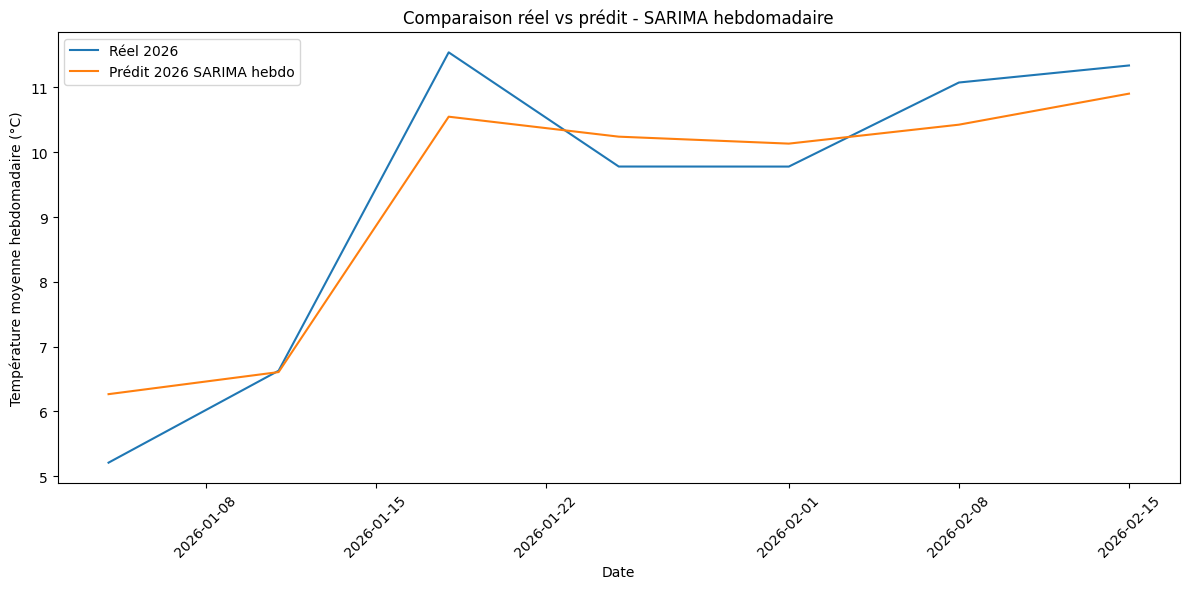

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1. CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

# =========================
# 2. PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# Conversion Kelvin -> Celsius
train["temperature"] = train["temperature"] - 273.15
test["temperature"] = test["temperature"] - 273.15

# =========================
# 3. AGRÉGATION HEBDOMADAIRE
# =========================
# "W" = une valeur par semaine

train_weekly = train.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()
test_weekly = test.groupby(pd.Grouper(key="date", freq="W"))["temperature"].mean()

# Si besoin, interpolation des semaines manquantes
train_weekly = train_weekly.asfreq("W").interpolate()
test_weekly = test_weekly.asfreq("W").interpolate()

print(train_weekly.head())
print(test_weekly.head())

# =========================
# 4. MODÈLE SARIMA HEBDOMADAIRE
# =========================
# order = (p, d, q)
# seasonal_order = (P, D, Q, s)
# s = 52 pour une saisonnalité annuelle sur des données hebdomadaires

model = SARIMAX(
    train_weekly,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =========================
# 5. PRÉVISION 2026
# =========================

n_steps = len(test_weekly)

forecast = results.forecast(steps=n_steps)
forecast.index = test_weekly.index

# =========================
# 6. TABLEAU COMPARATIF
# =========================

comparaison = pd.DataFrame({
    "temperature_reelle": test_weekly,
    "temperature_predite": forecast
})

print(comparaison.head())

# =========================
# 7. MÉTRIQUES
# =========================

mae = mean_absolute_error(comparaison["temperature_reelle"], comparaison["temperature_predite"])
mse = mean_squared_error(comparaison["temperature_reelle"], comparaison["temperature_predite"])
rmse = np.sqrt(mse)
r2 = r2_score(comparaison["temperature_reelle"], comparaison["temperature_predite"])

print("=== SARIMA hebdomadaire ===")
print("MAE :", mae, "°C")
print("MSE :", mse)
print("RMSE :", rmse, "°C")
print("R² :", r2)

# =========================
# 8. GRAPHIQUE
# =========================

plt.figure(figsize=(12, 6))
plt.plot(comparaison.index, comparaison["temperature_reelle"], label="Réel 2026")
plt.plot(comparaison.index, comparaison["temperature_predite"], label="Prédit 2026 SARIMA hebdo")

plt.xlabel("Date")
plt.ylabel("Température moyenne hebdomadaire (°C)")
plt.title("Comparaison réel vs prédit - SARIMA hebdomadaire")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

la version n'est pas correct

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

results_sarimax = model_sarimax.fit(disp=False)

y_pred_sarimax = results_sarimax.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)
mse_sarimax = mean_squared_error(y_test, y_pred_sarimax)
rmse_sarimax = np.sqrt(mse_sarimax)
r2_sarimax = r2_score(y_test, y_pred_sarimax)

print("=== SARIMAX ===")
print("MAE :", mae_sarimax)
print("MSE :", mse_sarimax)
print("RMSE :", rmse_sarimax)
print("R² :", r2_sarimax)

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Réel")
plt.plot(y_test.index, y_pred_sarimax, label="Prédit SARIMAX")
plt.xlabel("Date")
plt.ylabel("Température")
plt.title("SARIMAX : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ValueError: Provided exogenous values are not of the appropriate shape. Required (41, 7), got (41, 4).

Tableau final pour comparer

In [29]:
resultats = pd.DataFrame({
    "Modele": ["Régression linéaire", "Random Forest", "SARIMAX"],
    "MAE": [mae_lr, mae_rf, mae_sarimax],
    "MSE": [mse_lr, mse_rf, mse_sarimax],
    "RMSE": [rmse_lr, rmse_rf, rmse_sarimax],
    "R2": [r2_lr, r2_rf, r2_sarimax]
})

print(resultats)

NameError: name 'mae_rf' is not defined

Trois modèles ont été testés : une régression linéaire, un Random Forest et un modèle SARIMAX.

Les résultats montrent que le modèle SARIMAX est le plus performant, avec une erreur moyenne (MAE) d’environ 0.13°C et un RMSE de 0.16°C, ce qui indique une très grande précision des prédictions.

Ce modèle est plus efficace car il prend en compte à la fois la dépendance temporelle des données et les variables explicatives météorologiques.

Le modèle Random Forest est moins performant car il ne prend pas en compte explicitement la dimension temporelle des données, contrairement au modèle SARIMAX.

## Amélioration du modèle SARIMAX

Bloc propre de préparation des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

query = """
SELECT date,
       temperature,
       humidite,
       point_de_rose,
       temperature_min_sol_12h,
       precipitations_dernieres_24h
FROM releve_meteo
"""
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# Conversion Kelvin -> Celsius
def kelvin_to_celsius(df):
    df = df.copy()
    df["temperature"] = df["temperature"] - 273.15
    df["point_de_rose"] = df["point_de_rose"] - 273.15
    df["temperature_min_sol_12h"] = df["temperature_min_sol_12h"] - 273.15
    return df

train = kelvin_to_celsius(train)
test = kelvin_to_celsius(test)

cols = [
    "temperature",
    "humidite",
    "point_de_rose",
    "temperature_min_sol_12h",
    "precipitations_dernieres_24h"
]

train = train.groupby("date")[cols].mean()
test = test.groupby("date")[cols].mean()

train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

train = train.dropna()
test = test.dropna()

features = [
    "humidite",
    "point_de_rose",
    "temperature_min_sol_12h",
    "precipitations_dernieres_24h"
]

X_train = train[features]
y_train = train["temperature"]

X_test = test[features]
y_test = test["temperature"]

print("Taille train :", train.shape)
print("Taille test :", test.shape)
print("Période test :", y_test.index.min(), "->", y_test.index.max())

/tmp/ipykernel_165/965658745.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


Taille train : (1461, 5)
Taille test : (41, 5)
Période test : 2026-01-01 00:00:00 -> 2026-02-10 00:00:00


Bloc pour tester plusieurs modèles SARIMAX

In [ ]:
def evaluer_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

orders = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2),
    (3, 1, 1)
]

seasonal_orders = [
    (0, 0, 0, 0),   # sans saisonnalité
    (1, 1, 1, 7)    # saisonnalité hebdomadaire
]

liste_resultats = []
meilleur_modele = None
meilleur_resultat_fit = None
meilleure_prediction = None
meilleur_rmse = float("inf")
meilleure_config = None

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            y_pred = results.predict(
                start=len(y_train),
                end=len(y_train) + len(y_test) - 1,
                exog=X_test
            )

            mae, mse, rmse, r2 = evaluer_predictions(y_test, y_pred)

            liste_resultats.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "R2": r2,
                "AIC": results.aic
            })

            print(f"order={order} | seasonal_order={seasonal_order} | RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}")

            if rmse < meilleur_rmse:
                meilleur_rmse = rmse
                meilleure_config = (order, seasonal_order)
                meilleur_modele = model
                meilleur_resultat_fit = results
                meilleure_prediction = y_pred

        except Exception as e:
            print(f"Erreur avec order={order} et seasonal_order={seasonal_order} : {e}")

Erreur avec order=(1, 1, 1) et seasonal_order=(0, 0, 0, 0) : name 'SARIMAX' is not defined
Erreur avec order=(1, 1, 1) et seasonal_order=(1, 1, 1, 7) : name 'SARIMAX' is not defined
Erreur avec order=(1, 1, 2) et seasonal_order=(0, 0, 0, 0) : name 'SARIMAX' is not defined
Erreur avec order=(1, 1, 2) et seasonal_order=(1, 1, 1, 7) : name 'SARIMAX' is not defined
Erreur avec order=(2, 1, 1) et seasonal_order=(0, 0, 0, 0) : name 'SARIMAX' is not defined
Erreur avec order=(2, 1, 1) et seasonal_order=(1, 1, 1, 7) : name 'SARIMAX' is not defined
Erreur avec order=(2, 1, 2) et seasonal_order=(0, 0, 0, 0) : name 'SARIMAX' is not defined
Erreur avec order=(2, 1, 2) et seasonal_order=(1, 1, 1, 7) : name 'SARIMAX' is not defined
Erreur avec order=(3, 1, 1) et seasonal_order=(0, 0, 0, 0) : name 'SARIMAX' is not defined
Erreur avec order=(3, 1, 1) et seasonal_order=(1, 1, 1, 7) : name 'SARIMAX' is not defined


Tableau final de comparaison des configurations

In [ ]:
resultats_sarimax = pd.DataFrame(liste_resultats)
resultats_sarimax = resultats_sarimax.sort_values("RMSE").reset_index(drop=True)

print("\n=== Tableau des configurations SARIMAX ===")
print(resultats_sarimax)

print("\n=== Meilleure configuration ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print("RMSE :", resultats_sarimax.loc[0, "RMSE"])
print("MAE :", resultats_sarimax.loc[0, "MAE"])
print("R² :", resultats_sarimax.loc[0, "R2"])
print("AIC :", resultats_sarimax.loc[0, "AIC"])


=== Tableau des configurations SARIMAX ===
       order seasonal_order       MAE       MSE      RMSE        R2  \
0  (1, 1, 2)   (0, 0, 0, 0)  0.123169  0.022515  0.150049  0.996218   
1  (3, 1, 1)   (0, 0, 0, 0)  0.124627  0.023007  0.151680  0.996136   
2  (2, 1, 1)   (0, 0, 0, 0)  0.124712  0.023051  0.151827  0.996128   
3  (2, 1, 2)   (0, 0, 0, 0)  0.124725  0.023149  0.152149  0.996112   
4  (1, 1, 2)   (1, 1, 1, 7)  0.125098  0.023411  0.153006  0.996068   
5  (2, 1, 1)   (1, 1, 1, 7)  0.126374  0.023803  0.154283  0.996002   
6  (1, 1, 1)   (0, 0, 0, 0)  0.127359  0.024005  0.154936  0.995968   
7  (2, 1, 2)   (1, 1, 1, 7)  0.127140  0.024303  0.155895  0.995918   
8  (1, 1, 1)   (1, 1, 1, 7)  0.131282  0.025690  0.160280  0.995685   
9  (3, 1, 1)   (1, 1, 1, 7)  0.131495  0.026133  0.161658  0.995611   

           AIC  
0 -1426.072853  
1 -1435.338660  
2 -1413.944969  
3 -1429.250734  
4 -1378.731913  
5 -1364.399697  
6 -1398.263729  
7 -1380.833625  
8 -1348.318354  
9 -1

Graphique final propre du meilleur modèle

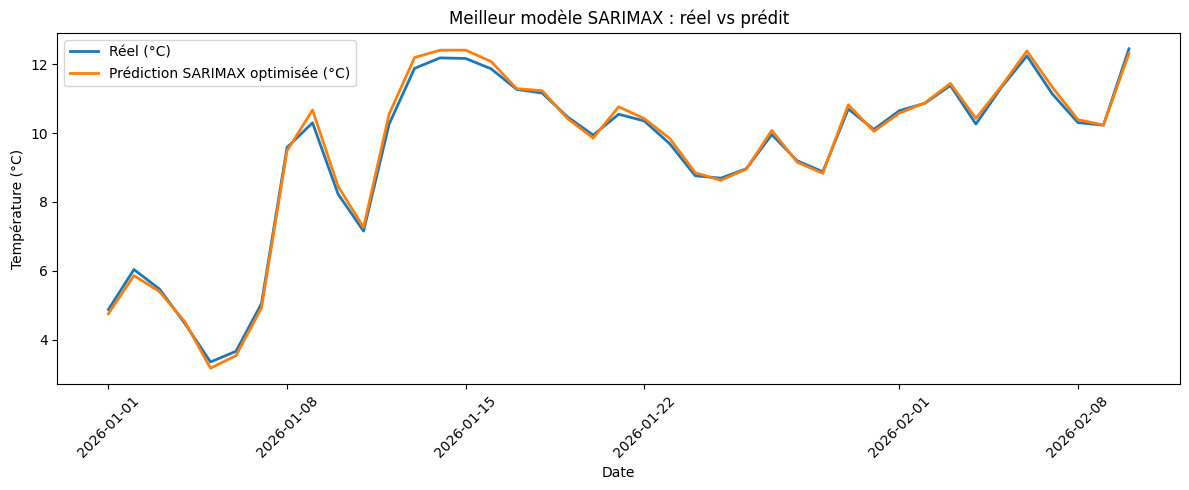

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Réel (°C)", linewidth=2)
plt.plot(y_test.index, meilleure_prediction, label="Prédiction SARIMAX optimisée (°C)", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Meilleur modèle SARIMAX : réel vs prédit")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Affichage final propre des métriques du meilleur modèle

In [ ]:
mae_best, mse_best, rmse_best, r2_best = evaluer_predictions(y_test, meilleure_prediction)

print("=== Meilleur SARIMAX optimisé ===")
print("order :", meilleure_config[0])
print("seasonal_order :", meilleure_config[1])
print("MAE :", mae_best, "°C")
print("MSE :", mse_best)
print("RMSE :", rmse_best, "°C")
print("R² :", r2_best)

=== Meilleur SARIMAX optimisé ===
order : (1, 1, 2)
seasonal_order : (0, 0, 0, 0)
MAE : 0.12316935281498803 °C
MSE : 0.022514836077074787
RMSE : 0.15004944544074392 °C
R² : 0.9962183307844386


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_sarimax_year = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 365),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_sarimax_year = model_sarimax_year.fit(disp=False)

y_pred_year = result_sarimax_year.predict(
    start=len(y_train),
    end=len(y_train) + len(X_test) - 1,
    exog=X_test
)

mae_year = mean_absolute_error(y_test, y_pred_year)
mse_year = mean_squared_error(y_test, y_pred_year)
rmse_year = np.sqrt(mse_year)
r2_year = r2_score(y_test, y_pred_year)

print("=== SARIMAX saisonnalité annuelle ===")
print("MAE :", mae_year)
print("RMSE :", rmse_year)
print("R2 :", r2_year)

/tmp/ipykernel_5598/2440618916.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


=== SARIMA sans données 2026 en entrée ===
MAE : 4.950370245387905 °C
MSE : 29.45815519336033
RMSE : 5.427536751912449 °C
R² : -3.947892947592636


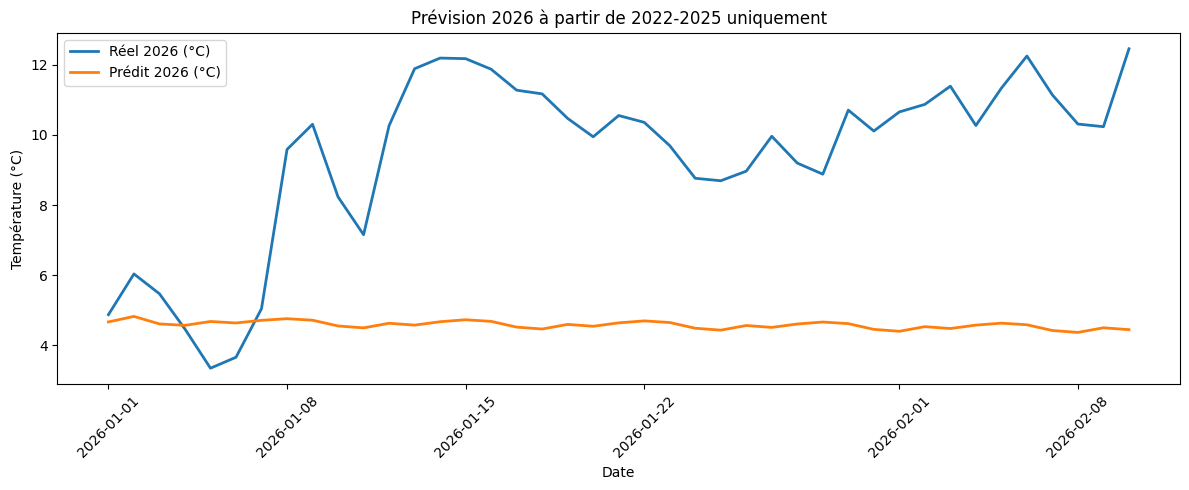

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = """
SELECT date, temperature
FROM releve_meteo
"""
train = pd.read_sql(query, bdd)

test = pd.read_csv("meteo_2026_a_predire.csv")

# =========================
# 2) PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"], dayfirst=True)

train = train.sort_values("date")
test = test.sort_values("date")

# Conversion Kelvin -> Celsius
train["temperature"] = train["temperature"] - 273.15
test["temperature"] = test["temperature"] - 273.15

# Agrégation journalière
train = train.groupby("date")["temperature"].mean()
test = test.groupby("date")["temperature"].mean()

# Fréquence journalière
train = train.asfreq("D").interpolate()
test = test.asfreq("D").interpolate()

# =========================
# 3) MODÈLE SARIMA
# =========================

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# Nombre de jours à prédire = longueur du vrai 2026
n_forecast = len(test)

forecast = results.forecast(steps=n_forecast)

# =========================
# 4) ÉVALUATION
# =========================

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
r2 = r2_score(test, forecast)

print("=== SARIMA sans données 2026 en entrée ===")
print("MAE :", mae, "°C")
print("MSE :", mse)
print("RMSE :", rmse, "°C")
print("R² :", r2)

# =========================
# 5) GRAPHIQUE
# =========================

plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label="Réel 2026 (°C)", linewidth=2)
plt.plot(test.index, forecast, label="Prédit 2026 (°C)", linewidth=2)

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Prévision 2026 à partir de 2022-2025 uniquement")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5598/1354373080.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


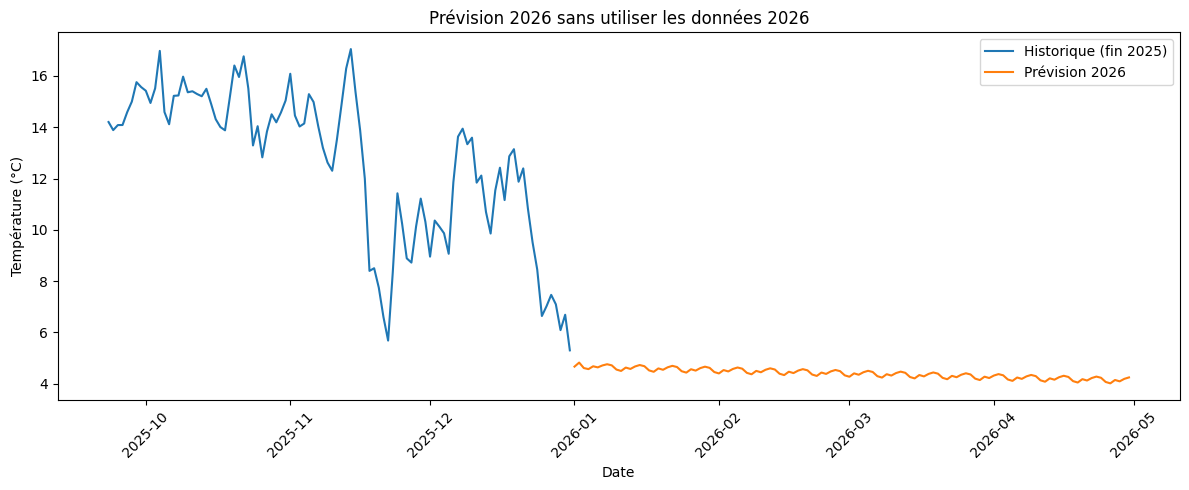

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

# =========================
# 2) PRÉPARATION
# =========================

train['date'] = pd.to_datetime(train['date'])
train = train.sort_values('date')

# Conversion Kelvin → Celsius
train['temperature'] = train['temperature'] - 273.15

# Agrégation journalière
train = train.groupby('date')['temperature'].mean()

# Fréquence journalière
train = train.asfreq('D').interpolate()

# =========================
# 3) MODÈLE SARIMA
# =========================

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =========================
# 4) PRÉVISION 2026
# =========================

# Exemple : 120 jours (~4 mois)
forecast_steps = 120

forecast = results.forecast(steps=forecast_steps)

# Générer les dates futures
future_dates = pd.date_range(
    start=train.index[-1] + pd.Timedelta(days=1),
    periods=forecast_steps,
    freq='D'
)

# =========================
# 5) GRAPHIQUE
# =========================

plt.figure(figsize=(12,5))

plt.plot(train.index[-100:], train.values[-100:], label="Historique (fin 2025)")
plt.plot(future_dates, forecast, label="Prévision 2026")

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("Prévision 2026 sans utiliser les données 2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

# =========================
# 2) PRÉPARATION
# =========================

train['date'] = pd.to_datetime(train['date'])
train = train.sort_values('date')

# Kelvin → Celsius
train['temperature'] = train['temperature'] - 273.15

# Agrégation journalière
train = train.groupby('date')['temperature'].mean()

# Fréquence journalière + interpolation
train = train.asfreq('D').interpolate()

# =========================
# 3) MODÈLE SARIMA
# =========================

model = SARIMAX(
    train,
    order=(2,1,1),              # à ajuster si besoin
    seasonal_order=(1,1,1,100),   # saisonnalité hebdomadaire
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =========================
# 4) PRÉDICTION FUTUR
# =========================

# Exemple : 120 jours (~4 mois)
n_steps = 120

forecast = results.forecast(steps=n_steps)

# Dates futures
future_dates = pd.date_range(
    start=train.index[-1] + pd.Timedelta(days=1),
    periods=n_steps,
    freq='D'
)

# =========================
# 5) VISUALISATION
# =========================

plt.figure(figsize=(12,5))

# Historique récent
plt.plot(train.index[-100:], train.values[-100:], label="Historique (fin 2025)")
plt.plot(future_dates, forecast, label="Prévision 2026")

# Prévision
plt.plot(future_dates, forecast, label="Prévision 2026")

plt.xlabel("Date")
plt.ylabel("Température (°C)")
plt.title("SARIMA : Prévision de température sans variables explicatives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_547/700713311.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


KeyboardInterrupt: 

mois

/tmp/ipykernel_547/3706328364.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  train = pd.read_sql(query, bdd)


date
2022-01-31     9.541434
2022-02-28    11.206093
2022-03-31    12.630924
2022-04-30    14.045257
2022-05-31    18.041148
Freq: ME, Name: temperature, dtype: float64
date
2025-08-31    21.243919
2025-09-30    17.473606
2025-10-31    14.961238
2025-11-30    12.092311
2025-12-31    10.313370
Freq: ME, Name: temperature, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


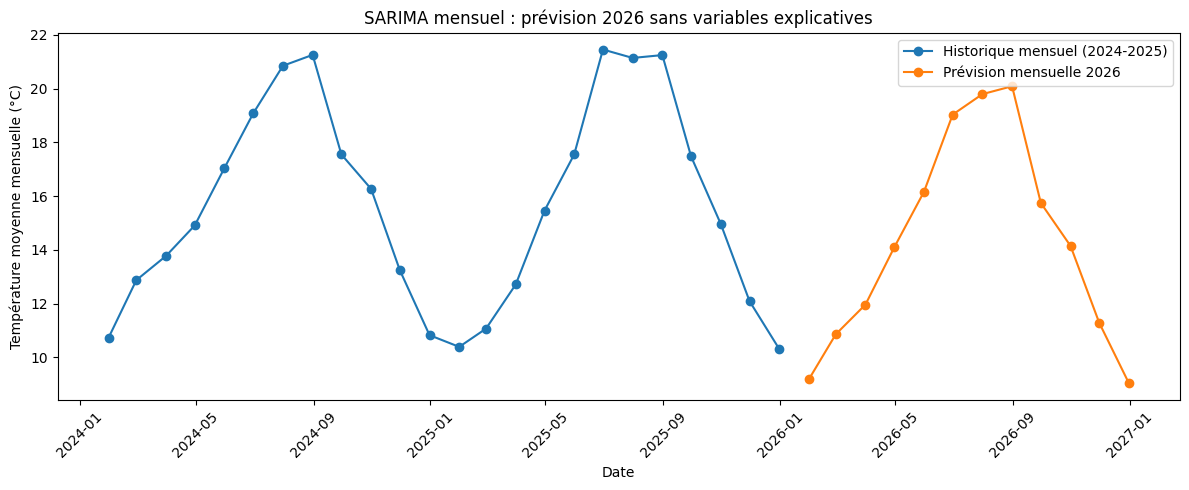

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================
# 1) CHARGER LES DONNÉES
# =========================

query = "SELECT date, temperature FROM releve_meteo"
train = pd.read_sql(query, bdd)

# =========================
# 2) PRÉPARATION
# =========================

train["date"] = pd.to_datetime(train["date"])
train = train.sort_values("date")

# Conversion Kelvin -> Celsius
train["temperature"] = train["temperature"] - 273.15

# Agrégation mensuelle
train_monthly = train.groupby(pd.Grouper(key="date", freq="ME"))["temperature"].mean()

# Vérification
print(train_monthly.head())
print(train_monthly.tail())

# =========================
# 3) MODÈLE SARIMA MENSUEL
# =========================

model = SARIMAX(
    train_monthly,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),  # saisonnalité annuelle sur données mensuelles
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# =========================
# 4) PRÉVISION 2026
# =========================

# 12 mois de prévision pour 2026
n_steps = 12

forecast = results.forecast(steps=n_steps)

# Dates futures mensuelles
future_dates = pd.date_range(
    start=train_monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=n_steps,
    freq="ME"
)

# =========================
# 5) GRAPHIQUE
# =========================

plt.figure(figsize=(12, 5))

# Historique récent : 24 derniers mois
plt.plot(
    train_monthly.index[-24:],
    train_monthly.values[-24:],
    label="Historique mensuel (2024-2025)",
    marker="o"
)

# Prévision 2026
plt.plot(
    future_dates,
    forecast,
    label="Prévision mensuelle 2026",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("SARIMA mensuel : prévision 2026 sans variables explicatives")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== SARIMA mensuel ===
MAE : 0.31946362917117543 °C
MSE : 0.11076238062554516
RMSE : 0.3328098265159026 °C
R² : 0.9168188286958384


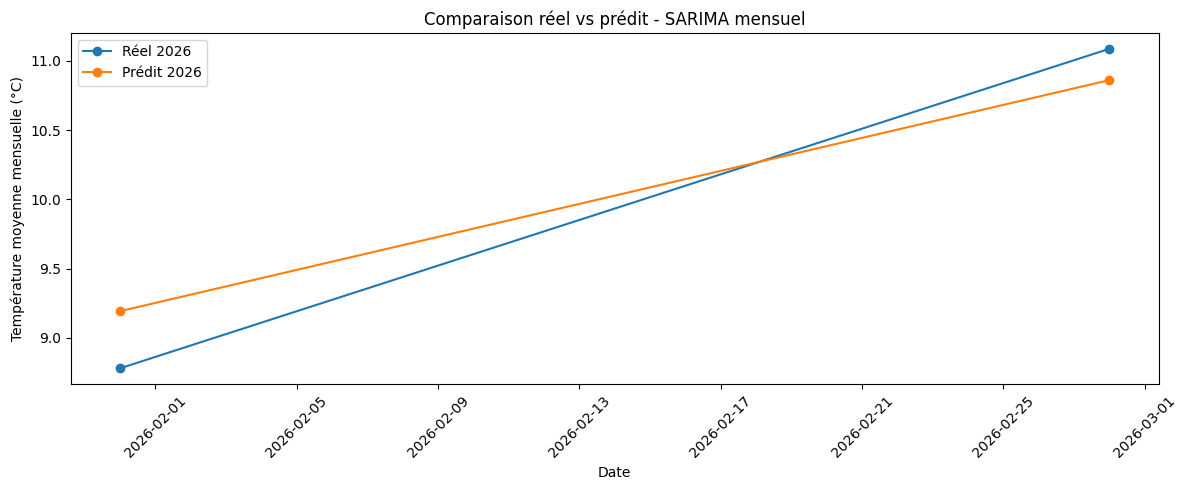

In [ ]:
# =========================
# 6) COMPARAISON AVEC LE RÉEL 2026 (OPTIONNEL)
# =========================

test = pd.read_csv("meteo_2026_a_predire.csv")

test["date"] = pd.to_datetime(test["date"], dayfirst=True)
test["temperature"] = test["temperature"] - 273.15

test_monthly = test.groupby(pd.Grouper(key="date", freq="ME"))["temperature"].mean()

# On aligne sur le nombre de mois disponibles
n_compare = min(len(test_monthly), len(forecast))

real_2026 = test_monthly.iloc[:n_compare]
pred_2026 = forecast.iloc[:n_compare]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(real_2026, pred_2026)
mse = mean_squared_error(real_2026, pred_2026)
rmse = np.sqrt(mse)
r2 = r2_score(real_2026, pred_2026)

print("=== SARIMA mensuel ===")
print("MAE :", mae, "°C")
print("MSE :", mse)
print("RMSE :", rmse, "°C")
print("R² :", r2)

plt.figure(figsize=(12, 5))
plt.plot(real_2026.index, real_2026.values, label="Réel 2026", marker="o")
plt.plot(real_2026.index, pred_2026.values, label="Prédit 2026", marker="o")
plt.xlabel("Date")
plt.ylabel("Température moyenne mensuelle (°C)")
plt.title("Comparaison réel vs prédit - SARIMA mensuel")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Régression linéaire simple

T demain = a *  T aujourd'hui + b * pression + c * humidité + d

/tmp/ipykernel_710/395359960.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve_meteo = pd.read_sql(query, bdd)


   releve_id        date  heure  temperature  point_de_rose  humidite  \
0          1  2022-01-01 0 days       284.45         283.35      93.0   
1          2  2022-01-01 0 days       278.85         278.45      97.0   
2          3  2022-01-01 0 days       280.05         279.95      99.0   
3          4  2022-01-01 0 days       282.25         282.25     100.0   
4          5  2022-01-01 0 days       284.25         281.25      82.0   

   temperature_min_sol_12h  precipitations_dernieres_24h  station_id  
0                   282.05                          -0.1           1  
1                   278.75                           0.0           2  
2                   281.85                           0.4           3  
3                   283.55                           0.4           4  
4                   284.05                           0.2           5  
Index(['releve_id', 'date', 'heure', 'temperature', 'point_de_rose',
       'humidite', 'temperature_min_sol_12h', 'precipitations_dern

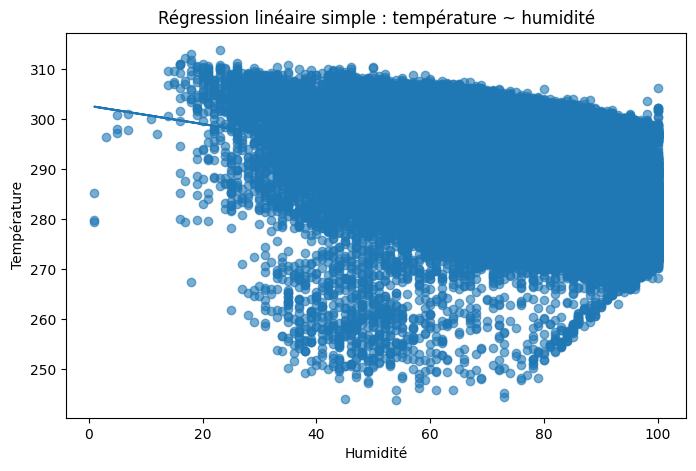

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Charger la table SQL
query = "SELECT * FROM releve_meteo"
releve_meteo = pd.read_sql(query, bdd)

# Vérification rapide
print(releve_meteo.head())
print(releve_meteo.columns)

# Garder les colonnes utiles
df = releve_meteo[['temperature', 'humidite']].dropna()

# Variable explicative
X = df[['humidite',
        'point_de_rose',
        'temperature_min_sol_12h',
        'precipitations_dernieres_24h']]


# Variable cible
y = df['temperature']

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Création du modèle
model = LinearRegression()

# Entraînement
model.fit(X_train, y_train)

# Prédictions
predictions = model.predict(X_test)

# Résultats
print("Coefficient (pente) :", model.coef_[0])
print("Intercept :", model.intercept_)
print("MSE :", mean_squared_error(y_test, predictions))
print("R² :", r2_score(y_test, predictions))

# Graphique
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.6)
plt.plot(X_test, predictions)
plt.xlabel("Humidité")
plt.ylabel("Température")
plt.title("Régression linéaire simple : température ~ humidité")
plt.show()


-----------------------------
Variable explicative : humidite
Coefficient : -0.2348387826234485
Intercept : 304.6501931448168
MSE : 42.02855760202253
R² : 0.285377845888804

-----------------------------
Variable explicative : point_de_rose
Coefficient : 1.0206738706643157
Intercept : -1.384224379988325
MSE : 18.333938831411917
R² : 0.6882634187661012

-----------------------------
Variable explicative : temperature_min_sol_12h
Coefficient : 0.9388473299869234
Intercept : 20.305617758560345
MSE : 18.741493553581925
R² : 0.6813336631405762

-----------------------------
Variable explicative : precipitations_dernieres_24h
Coefficient : 0.029541717476252356
Intercept : 286.4291631414743
MSE : 58.77222074710424
R² : 0.0006811228236581757


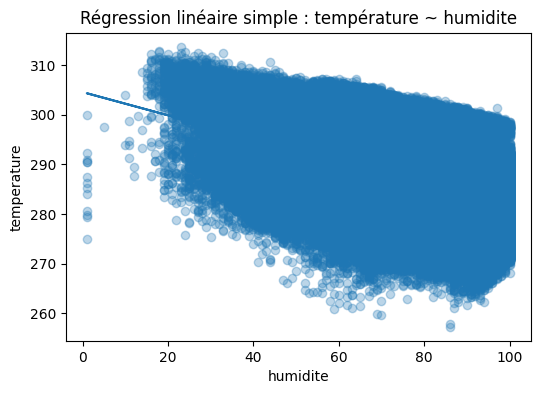

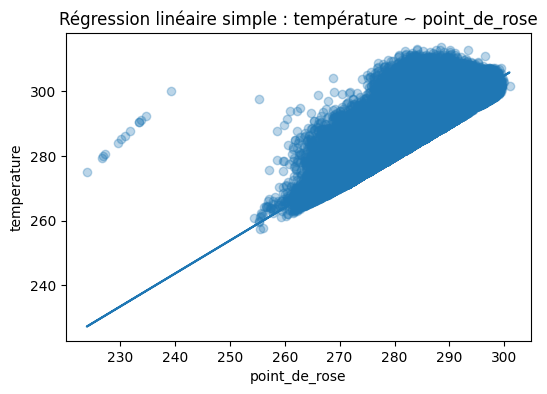

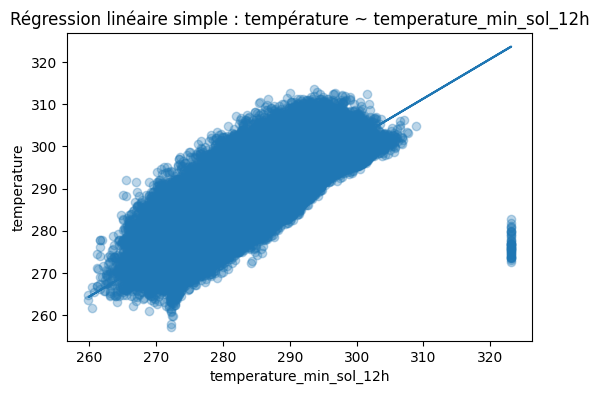

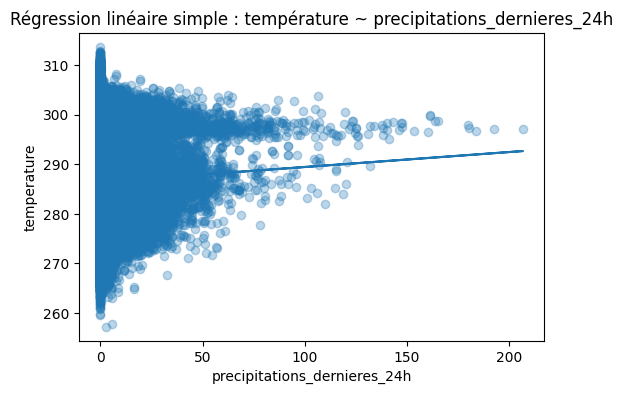

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# garder les colonnes utiles
df = releve_meteo[['temperature',
                   'humidite',
                   'point_de_rose',
                   'temperature_min_sol_12h',
                   'precipitations_dernieres_24h']].dropna()

# variables explicatives
variables = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

for var in variables:

    X = df[[var]]
    y = df['temperature']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\n-----------------------------")
    print("Variable explicative :", var)
    print("Coefficient :", model.coef_[0])
    print("Intercept :", model.intercept_)
    print("MSE :", mean_squared_error(y_test, pred))
    print("R² :", r2_score(y_test, pred))

    import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

variables = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

df = releve_meteo[['temperature',
                   'humidite',
                   'point_de_rose',
                   'temperature_min_sol_12h',
                   'precipitations_dernieres_24h']].dropna()

for var in variables:

    X = df[[var]]
    y = df['temperature']

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    plt.figure(figsize=(6,4))

    plt.scatter(X, y, alpha=0.3)

    # droite de régression
    plt.plot(X, y_pred)

    plt.xlabel(var)
    plt.ylabel("temperature")

    plt.title(f"Régression linéaire simple : température ~ {var}")

    plt.show()

ARIMA

/tmp/ipykernel_710/690332139.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve_meteo = pd.read_sql(query, bdd)


Aperçu de la série temporelle :
date
2022-01-01    285.108824
2022-01-02    286.416968
2022-01-03    286.736325
2022-01-04    286.144068
2022-01-05    283.256957
Name: temperature, dtype: float64


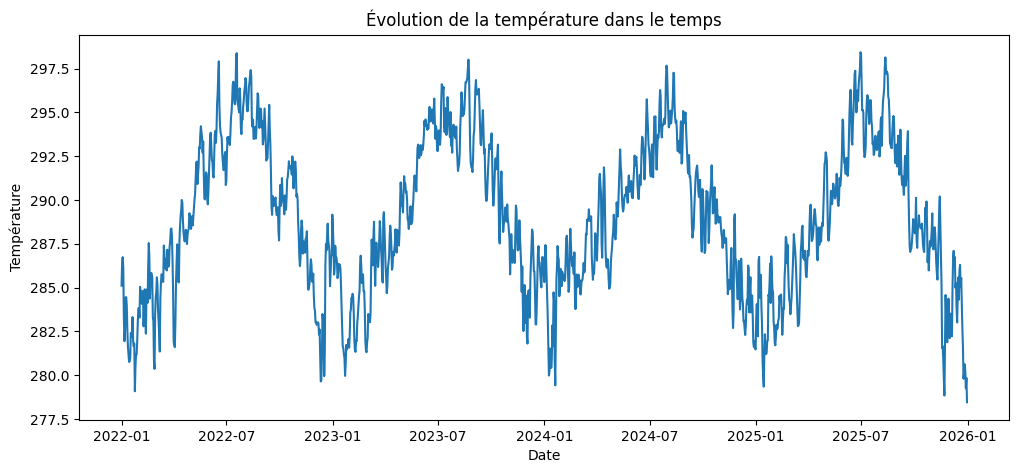


Taille train : 1431
Taille test : 30


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



Résumé du modèle ARIMA :
                               SARIMAX Results                                
Dep. Variable:            temperature   No. Observations:                 1431
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1962.033
Date:                Wed, 11 Mar 2026   AIC                           3930.066
Time:                        09:18:52   BIC                           3945.863
Sample:                    01-01-2022   HQIC                          3935.965
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3000      0.064     -4.671      0.000      -0.426      -0.174
ma.L1          0.6098      0.053     11.452      0.000       0.505       0.714
sigma2         0.9104     

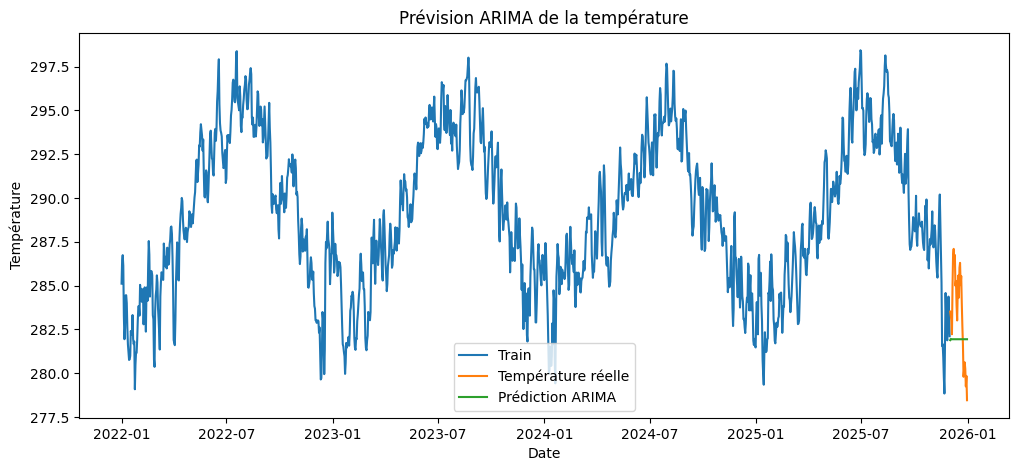

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Charger la table SQL
query = "SELECT * FROM releve_meteo"
releve_meteo = pd.read_sql(query, bdd)

# 2. Préparer les données
releve_meteo['date'] = pd.to_datetime(releve_meteo['date'])
releve_meteo = releve_meteo.sort_values('date')

# 3. Créer une série temporelle journalière
# On prend la moyenne de la température par jour
serie_temp = releve_meteo.groupby('date')['temperature'].mean().dropna()

print("Aperçu de la série temporelle :")
print(serie_temp.head())

# 4. Visualiser la série
plt.figure(figsize=(12, 5))
plt.plot(serie_temp)
plt.title("Évolution de la température dans le temps")
plt.xlabel("Date")
plt.ylabel("Température")
plt.show()

# 5. Séparer train / test
# On garde les 30 derniers jours pour le test
train = serie_temp[:-30]
test = serie_temp[-30:]

print("\nTaille train :", len(train))
print("Taille test :", len(test))

# 6. Créer et entraîner le modèle ARIMA
# order=(p,d,q)
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

print("\nRésumé du modèle ARIMA :")
print(model_fit.summary())

# 7. Faire les prédictions sur la période de test
forecast = model_fit.forecast(steps=len(test))

# 8. Évaluer les performances
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("\nRésultats du modèle :")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

# 9. Afficher valeurs réelles vs prédites
comparaison = pd.DataFrame({
    'Reel': test,
    'Prediction': forecast
})

print("\nComparaison réel / prédiction :")
print(comparaison.head(10))

# 10. Visualiser la prédiction
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Température réelle')
plt.plot(test.index, forecast, label='Prédiction ARIMA')
plt.title("Prévision ARIMA de la température")
plt.xlabel("Date")
plt.ylabel("Température")
plt.legend()
plt.show()

ARIMAX

/tmp/ipykernel_710/760729174.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve_meteo = pd.read_sql(query, bdd)


Train : 1431
Test : 30


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            temperature   No. Observations:                 1431
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 706.678
Date:                Wed, 11 Mar 2026   AIC                          -1399.356
Time:                        09:28:11   BIC                          -1362.498
Sample:                    01-01-2022   HQIC                         -1385.592
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
humidite                        -0.2468      0.001   -174.866      0.000      -0.250      -0.244
point_de_rose                    1.0870      0.006    168.059      0.000     

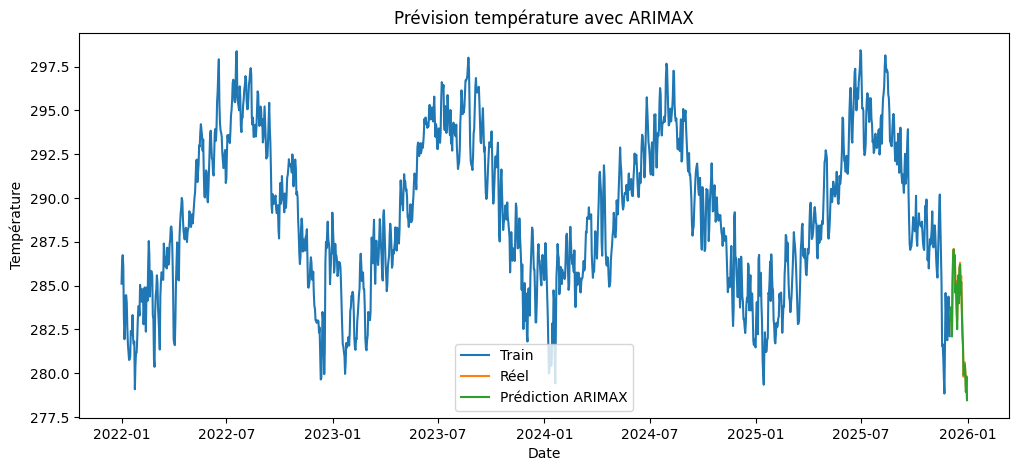

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Charger la table
query = "SELECT * FROM releve_meteo"
releve_meteo = pd.read_sql(query, bdd)

# 2. Préparer les données
releve_meteo['date'] = pd.to_datetime(releve_meteo['date'])
releve_meteo = releve_meteo.sort_values('date')

# 3. Moyenne journalière
data = releve_meteo.groupby('date').mean()

# 4. Variable cible
y = data['temperature']

# 5. Variables explicatives
X = data[['humidite',
          'point_de_rose',
          'temperature_min_sol_12h',
          'precipitations_dernieres_24h']]

# supprimer les NA
dataset = pd.concat([y, X], axis=1).dropna()

y = dataset['temperature']
X = dataset[['humidite',
             'point_de_rose',
             'temperature_min_sol_12h',
             'precipitations_dernieres_24h']]

# 6. train / test
train_y = y[:-30]
test_y = y[-30:]

train_X = X[:-30]
test_X = X[-30:]

print("Train :", len(train_y))
print("Test :", len(test_y))

# 7. Modèle ARIMAX
model = SARIMAX(train_y,
                exog=train_X,
                order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

# 8. Prédictions
forecast = model_fit.forecast(steps=len(test_y),
                              exog=test_X)

# 9. Évaluation
mae = mean_absolute_error(test_y, forecast)
mse = mean_squared_error(test_y, forecast)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

# 10. Comparaison
comparaison = pd.DataFrame({
    'Reel': test_y,
    'Prediction': forecast
})

print(comparaison.head())

# 11. Graphique
plt.figure(figsize=(12,5))

plt.plot(train_y.index, train_y, label="Train")
plt.plot(test_y.index, test_y, label="Réel")
plt.plot(test_y.index, forecast, label="Prédiction ARIMAX")

plt.title("Prévision température avec ARIMAX")
plt.xlabel("Date")
plt.ylabel("Température")

plt.legend()

plt.show()

La comparaison entre les valeurs réelles et les valeurs prédites montre que le modèle reproduit correctement les fluctuations de la température. Les prédictions sont très proches des observations réelles, avec des écarts généralement faibles. Cela indique que le modèle capture efficacement la dynamique temporelle de la série ainsi que l’influence des variables météorologiques.

SARIMA

/tmp/ipykernel_710/3185662372.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve_meteo = pd.read_sql(query, bdd)


Aperçu de la série :
date
2022-01-01    285.108824
2022-01-02    286.416968
2022-01-03    286.736325
2022-01-04    286.144068
2022-01-05    283.256957
Name: temperature, dtype: float64


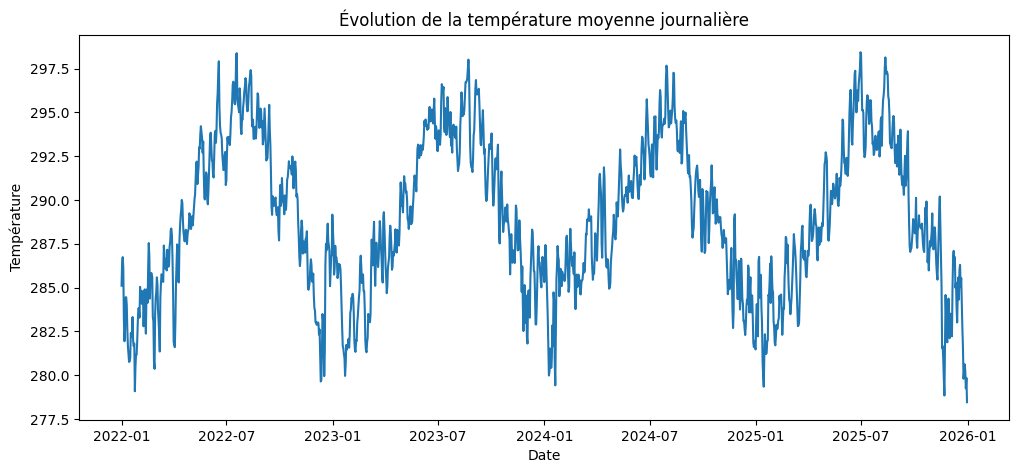


Période train : 2022-01-01 00:00:00 à 2025-12-01 00:00:00
Période test  : 2025-12-02 00:00:00 à 2025-12-31 00:00:00
Taille train : 1431
Taille test : 30

Résumé du modèle SARIMA :
                                     SARIMAX Results                                     
Dep. Variable:                       temperature   No. Observations:                 1431
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1948.372
Date:                           Wed, 11 Mar 2026   AIC                           3906.744
Time:                                   09:35:33   BIC                           3933.015
Sample:                               01-01-2022   HQIC                          3916.559
                                    - 12-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------

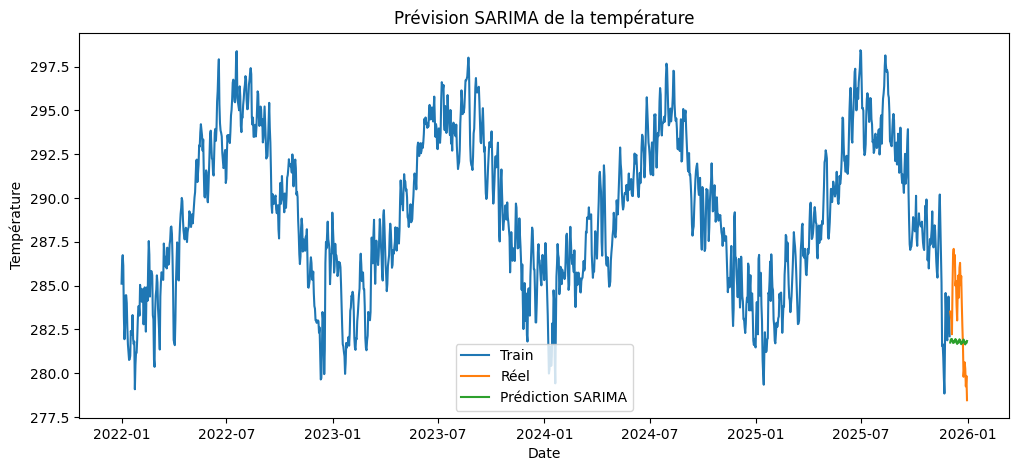

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Charger la table SQL
query = "SELECT * FROM releve_meteo"
releve_meteo = pd.read_sql(query, bdd)

# 2. Préparer les données
releve_meteo['date'] = pd.to_datetime(releve_meteo['date'])
releve_meteo = releve_meteo.sort_values('date')

# 3. Série temporelle journalière : moyenne de la température par jour
serie_temp = releve_meteo.groupby('date')['temperature'].mean().dropna()

print("Aperçu de la série :")
print(serie_temp.head())

# 4. Forcer la fréquence journalière
serie_temp = serie_temp.asfreq('D')

# 5. Vérifier les valeurs manquantes éventuelles
serie_temp = serie_temp.interpolate()

# 6. Visualisation
plt.figure(figsize=(12,5))
plt.plot(serie_temp)
plt.title("Évolution de la température moyenne journalière")
plt.xlabel("Date")
plt.ylabel("Température")
plt.show()

# 7. Séparation train / test
train = serie_temp[:-30]
test = serie_temp[-30:]

print("\nPériode train :", train.index.min(), "à", train.index.max())
print("Période test  :", test.index.min(), "à", test.index.max())
print("Taille train :", len(train))
print("Taille test :", len(test))

# 8. Modèle SARIMA
# seasonal_order = (P, D, Q, s)
# Ici s=7 pour une saisonnalité hebdomadaire
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

print("\nRésumé du modèle SARIMA :")
print(model_fit.summary())

# 9. Prévision sur la période test
forecast = model_fit.forecast(steps=len(test))

# 10. Évaluation
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("\nRésultats du modèle SARIMA :")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)

# 11. Comparaison réel / prédit
comparaison = pd.DataFrame({
    'Reel': test,
    'Prediction': forecast
})

print("\nComparaison réel / prédiction :")
print(comparaison.head(10))

# 12. Graphique train / test / prédiction
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Réel')
plt.plot(test.index, forecast, label='Prédiction SARIMA')
plt.title("Prévision SARIMA de la température")
plt.xlabel("Date")
plt.ylabel("Température")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================================================
# 1) CHARGER L'HISTORIQUE DEPUIS MYSQL
# =========================================================
query = "SELECT * FROM releve_meteo"
releve_meteo = pd.read_sql(query, bdd)

# Mise au bon format
releve_meteo['date'] = pd.to_datetime(releve_meteo['date'])
releve_meteo = releve_meteo.sort_values('date')

# Agrégation journalière
historique = releve_meteo.groupby('date')[[
    'temperature',
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]].mean()

# Fréquence journalière + interpolation si besoin
historique = historique.asfreq('D')
historique = historique.interpolate()

# Variable cible
y_train = historique['temperature']

# Variables explicatives historiques
X_train = historique[[
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]]

print("Historique :")
print(historique.head())
print(historique.tail())

# =========================================================
# 2) CHARGER LE FICHIER 2026 A PREDIRE
# =========================================================
import os
print(os.listdir())
# Remplace le nom si besoin
future = pd.read_csv("meteo_2026_a_predire.csv")

print("\nColonnes du fichier futur :")
print(future.columns)

# Conversion date
future['date'] = pd.to_datetime(future['date'])
future = future.sort_values('date')

# Vérification des colonnes attendues
colonnes_exog = [
    'humidite',
    'point_de_rose',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h'
]

for col in colonnes_exog:
    if col not in future.columns:
        raise ValueError(f"La colonne '{col}' manque dans le fichier 2026.")

# Si le fichier contient plusieurs lignes par jour, on agrège par date
future = future.groupby('date')[colonnes_exog].mean()

# Fréquence journalière
future = future.asfreq('D')

# Remplir valeurs manquantes si besoin
future = future.interpolate().ffill().bfill()

print("\nAperçu variables explicatives 2026 :")
print(future.head())
print(future.tail())

# =========================================================
# 3) ENTRAINER LE MODELE ARIMAX
# =========================================================
# ARIMAX = SARIMAX sans saisonnalité
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

print("\nRésumé du modèle ARIMAX :")
print(model_fit.summary())

# =========================================================
# 4) PREDIRE 2026
# =========================================================
forecast_2026 = model_fit.forecast(
    steps=len(future),
    exog=future
)

# Mettre les résultats dans un dataframe
prediction_2026 = future.copy()
prediction_2026['temperature_predite'] = forecast_2026

print("\nPrévisions 2026 :")
print(prediction_2026.head(10))

# =========================================================
# 5) SAUVEGARDER LES PREDICTIONS
# =========================================================
prediction_2026.to_csv("prediction_temperature_2026_ARIMAX.csv")

print("\nFichier sauvegardé : prediction_temperature_2026_ARIMAX.csv")

# =========================================================
# 6) VISUALISATION
# =========================================================
plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train, label="Historique température")
plt.plot(prediction_2026.index, prediction_2026['temperature_predite'], label="Prédiction 2026")
plt.title("Prédiction ARIMAX de la température pour 2026")
plt.xlabel("Date")
plt.ylabel("Température")
plt.legend()
plt.show()

/tmp/ipykernel_710/992961167.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  releve_meteo = pd.read_sql(query, bdd)


Historique :
            temperature   humidite  point_de_rose  temperature_min_sol_12h  \
date                                                                         
2022-01-01   285.108824  81.401961     281.686275               279.450000   
2022-01-02   286.416968  79.425339     282.720136               280.091912   
2022-01-03   286.736325  82.119658     283.558547               280.884043   
2022-01-04   286.144068  80.610169     282.652119               280.744286   
2022-01-05   283.256957  77.360870     279.279130               277.338321   

            precipitations_dernieres_24h  
date                                      
2022-01-01                      0.594595  
2022-01-02                      0.662814  
2022-01-03                      1.131776  
2022-01-04                      5.442523  
2022-01-05                      3.898077  
            temperature   humidite  point_de_rose  temperature_min_sol_12h  \
date                                                         

FileNotFoundError: [Errno 2] No such file or directory: 'meteo_2026_a_predire.csv'

SARIMAX

Moyenne Mobile

In [ ]:
t prévue = (T1+...+Tn)/n

Random Forest Regressor